/home/u32/temakgoale/.local/lib/python3.8/site-packages/xarray/coding/times.py:250: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/home/u32/temakgoale/.local/lib/python3.8/site-packages/xarray/coding/times.py:250: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/tmp/ipykernel_25134/1511299636.py:57: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  valid_bt = (bt.values != -9999)


Processing: CWP
Processing: CIW
Processing: CLW


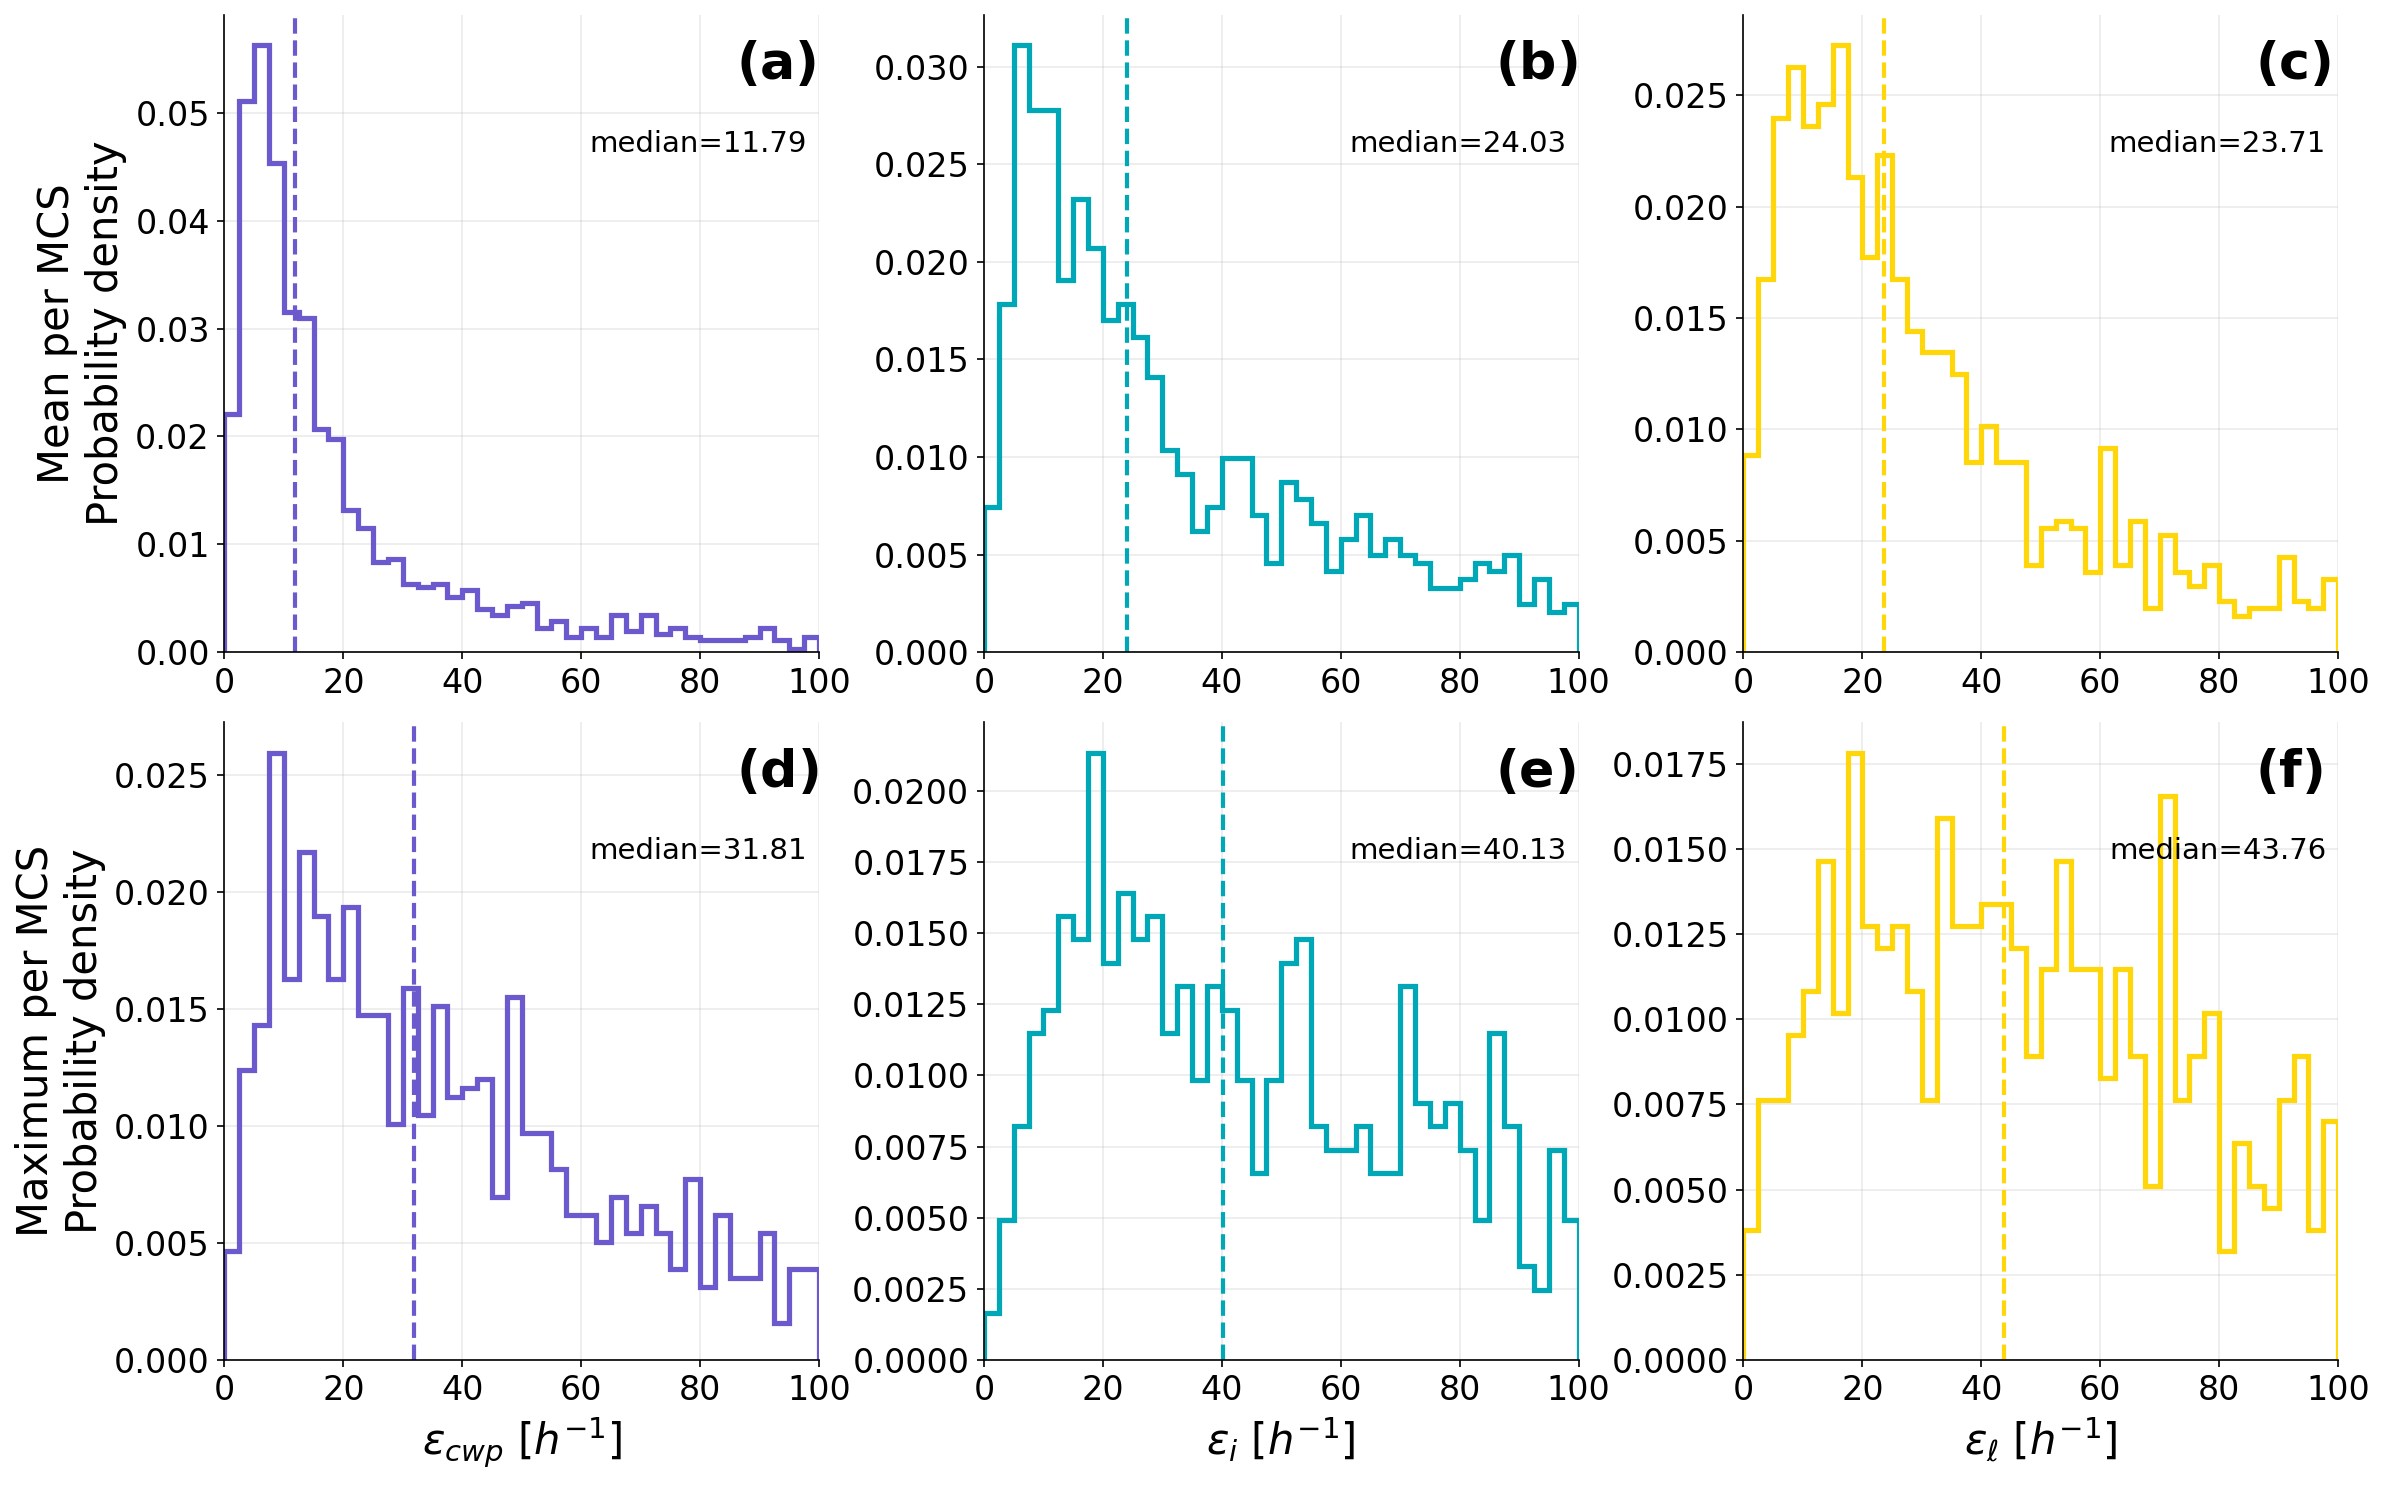

In [1]:
#!/usr/bin/env python3
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# USER INPUTS
# ===============================
basedir_eff = "/xdisk/sylvia/temakgoale/MCS_TRACKS_DATA/lifecyle/"

eff_specs = [
    ("CWP", basedir_eff + "precip_efficiency_gt1hr_cwp_fromPIXEL.nc", r"$\epsilon_{cwp}$"),
    ("CIW", basedir_eff + "precip_efficiency_gt1hr_ciw_fromPIXEL.nc", r"$\epsilon_{i}$"),
    ("CLW", basedir_eff + "precip_efficiency_gt1hr_clw_fromPIXEL.nc", r"$\epsilon_{\ell}$"),
]

mcs_file = "/xdisk/sylvia/temakgoale/MCS_TRACKS_DATA/Precipitation_Features/Asia_prec_features/mcs_tracks_pf_20160101.0000_20170101.0000_Asia.nc"
min_duration_hr = 4

# ===============================
# FIGURE SETTINGS
# ===============================
DPI = 150
FIGSIZE = (16, 10)
COLORS = ["#6A5ACD", "#00A7B7", "#FFD60A"]

# histogram settings
XMIN, XMAX = 0, 100
NBINS = 40
BINS = np.linspace(XMIN, XMAX, NBINS + 1)

# subplot labels (bold with brackets)
panel_labels = [
    r"$\mathbf{(a)}$", r"$\mathbf{(b)}$", r"$\mathbf{(c)}$",
    r"$\mathbf{(d)}$", r"$\mathbf{(e)}$", r"$\mathbf{(f)}$"
]

# ===============================
# LOAD TRACK DATA
# ===============================
mcs = xr.open_dataset(mcs_file)
bt = mcs["base_time"].load()

time_res_hr = float(mcs.attrs.get("time_resolution_hour", 0.5))
tracks_dim, times_dim = bt.shape

# ===============================
# FUNCTION: PER TRACK STATISTICS
# ===============================
def compute_track_stats(eff_file):

    eff_ds = xr.open_dataset(eff_file)

    eps = eff_ds["precip_efficiency"].load() * 3600.0
    eps_arr = eps.values

    valid_bt = (bt.values != -9999)
    valid_eps = np.isfinite(eps_arr)
    valid = valid_bt & valid_eps

    dur_steps = valid.sum(axis=1)
    dur_hours = dur_steps * time_res_hr
    keep_track = dur_hours > min_duration_hr

    means = []
    maxs = []

    for i in range(tracks_dim):

        if not keep_track[i]:
            continue

        series = eps_arr[i, valid[i]]
        series = series[np.isfinite(series)]

        if series.size < 1:
            continue

        means.append(np.nanmean(series))
        maxs.append(np.nanmax(series))

    eff_ds.close()

    return np.array(means), np.array(maxs)

# ===============================
# COMPUTE STATISTICS
# ===============================
means_all = []
max_all = []

for short, file, label in eff_specs:

    print("Processing:", short)

    m, mx = compute_track_stats(file)

    m = m[(m >= XMIN) & (m <= XMAX)]
    mx = mx[(mx >= XMIN) & (mx <= XMAX)]

    means_all.append(m)
    max_all.append(mx)

mcs.close()

# ===============================
# PLOT 2 × 3
# ===============================
fig, axes = plt.subplots(2, 3, figsize=FIGSIZE, dpi=DPI)

# ---------- TOP ROW: MEAN ----------
for i, (vals, spec) in enumerate(zip(means_all, eff_specs)):

    ax = axes[0, i]
    label = spec[2]

    ax.hist(
        vals,
        bins=BINS,
        density=True,
        histtype="step",
        linewidth=2.5,
        color=COLORS[i]
    )

    med = np.nanmedian(vals)

    ax.axvline(med, linestyle="--", linewidth=2, color=COLORS[i])
    ax.text(
        0.98, 0.82,
        f"median={med:.2f}",
        transform=ax.transAxes,
        fontsize=14,
        ha="right",
        va="top"
    )

    ax.set_xlim(XMIN, XMAX)
    ax.tick_params(axis="x", labelsize=16)
    ax.tick_params(axis="y", labelsize=16)

    if i == 0:
        ax.set_ylabel("Mean per MCS\nProbability density", fontsize=20)

    ax.grid(alpha=0.25)

# ---------- BOTTOM ROW: MAX ----------
for i, (vals, spec) in enumerate(zip(max_all, eff_specs)):

    ax = axes[1, i]
    label = spec[2]

    ax.hist(
        vals,
        bins=BINS,
        density=True,
        histtype="step",
        linewidth=2.5,
        color=COLORS[i]
    )

    med = np.nanmedian(vals)

    ax.axvline(med, linestyle="--", linewidth=2, color=COLORS[i])
    ax.text(
        0.98, 0.82,
        f"median={med:.2f}",
        transform=ax.transAxes,
        fontsize=14,
        ha="right",
        va="top"
    )

    ax.set_xlim(XMIN, XMAX)
    ax.set_xlabel(label + r" $[h^{-1}]$", fontsize=20)
    ax.tick_params(axis="x", labelsize=16)
    ax.tick_params(axis="y", labelsize=16)

    if i == 0:
        ax.set_ylabel("Maximum per MCS\nProbability density", fontsize=20)

    ax.grid(alpha=0.25)

# ===============================
# ADD SUBPLOT LABELS (a–f)
# ===============================
for ax, lab in zip(axes.flatten(), panel_labels):

    ax.text(
        0.86, 0.96,
        lab,
        transform=ax.transAxes,
        fontsize=25,
        va="top",
        ha="left"
    )

# remove top/right spines
for ax in axes.flatten():
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()

out_png = "/xdisk/sylvia/temakgoale/MCS_TRACKS_DATA/MCS_Paper_Plots/Figure2_MCS_distribution.png"
out_pdf = "/xdisk/sylvia/temakgoale/MCS_TRACKS_DATA/MCS_Paper_Plots/Figure2_MCS_distribution.pdf"

plt.savefig(out_png, dpi=200, bbox_inches="tight")
plt.savefig(out_pdf, dpi=200, bbox_inches="tight")

plt.show()